# Dataset Overivew

This dataset contains 7,500 synthetic digital payment transactions designed for fraud detection and financial risk modeling tasks.

The dataset includes transaction-level features such as transaction amount, payment mode, device type, account age, transaction timing, behavioral indicators, and a fraud label.

It is suitable for:

    Fraud detection classification models
    Imbalanced dataset handling practice
    Anomaly detection systems
    Feature engineering projects
    Financial analytics dashboards
    Risk scoring model development

The fraud_label column represents:

    0 = Legitimate transaction
    1 = Fraudulent transaction

This dataset is fully synthetic and created for educational, research, and machine learning experimentation purposes.

# Libraries

In [211]:
import pandas as pd # Data manipulation
import numpy as np # Data analysis
import matplotlib.pyplot as plt # Data visualization
import seaborn as sns # Data visualization

from sklearn.model_selection import train_test_split # Model selection
from sklearn.impute import SimpleImputer # Data imputation
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder # Data preprocessing
from sklearn.pipeline import Pipeline # Pipeline construction
from sklearn.compose import ColumnTransformer # Column transformation
from sklearn.linear_model import LogisticRegression # Logistic regression model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve


# Loading Data

In [212]:
df = pd.read_csv('dataset.csv') # Loading dataset

# Overview

In [213]:
df.head() # Previewing dataset

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


In [214]:
df.shape # Checking dataset shape

(7500, 15)

# Basic Statistics

In [215]:
df.describe() # Describing dataset statistics

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,24813.534161,1006.904533,11.435867,2.013600,15129.061027,0.100667,0.505026,4.995067,0.065200
std,14434.742371,575.632925,6.950899,1.421578,8597.760720,0.300907,0.289647,2.593879,0.246895
min,50.580000,10.000000,0.000000,0.000000,102.790000,0.000000,0.000000,1.000000,0.000000
25%,12272.785000,502.750000,5.000000,1.000000,7725.842500,0.000000,0.257000,3.000000,0.000000
50%,24715.550000,1018.000000,11.000000,2.000000,15074.810000,0.000000,0.502000,5.000000,0.000000
75%,37288.375000,1505.000000,18.000000,3.000000,22573.062500,0.000000,0.759000,7.000000,0.000000
max,49985.900000,1999.000000,23.000000,4.000000,29994.290000,1.000000,1.000000,9.000000,1.000000


# Data Info

In [216]:
df.info() # Checking dataset information

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            7500 non-null   str    
 1   user_id                   7500 non-null   str    
 2   transaction_amount        7500 non-null   float64
 3   transaction_type          7500 non-null   str    
 4   payment_mode              7500 non-null   str    
 5   device_type               7500 non-null   str    
 6   device_location           7500 non-null   str    
 7   account_age_days          7500 non-null   int64  
 8   transaction_hour          7500 non-null   int64  
 9   previous_failed_attempts  7500 non-null   int64  
 10  avg_transaction_amount    7500 non-null   float64
 11  is_international          7500 non-null   int64  
 12  ip_risk_score             7500 non-null   float64
 13  login_attempts_last_24h   7500 non-null   int64  
 14  fraud_label        

# Null

In [217]:
df.isna().sum() # Checking for missing values

transaction_id              0
user_id                     0
transaction_amount          0
transaction_type            0
payment_mode                0
device_type                 0
device_location             0
account_age_days            0
transaction_hour            0
previous_failed_attempts    0
avg_transaction_amount      0
is_international            0
ip_risk_score               0
login_attempts_last_24h     0
fraud_label                 0
dtype: int64

# Duplicate

In [218]:
df.duplicated().sum() # Checking for duplicate values

np.int64(0)

In [219]:
df_clean = df.copy() # Copying dataset to avoid modifying original dataset

In [220]:
df_clean.head() # Previewing cleaned dataset

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


# Exploratory Data Analysis (EDA)

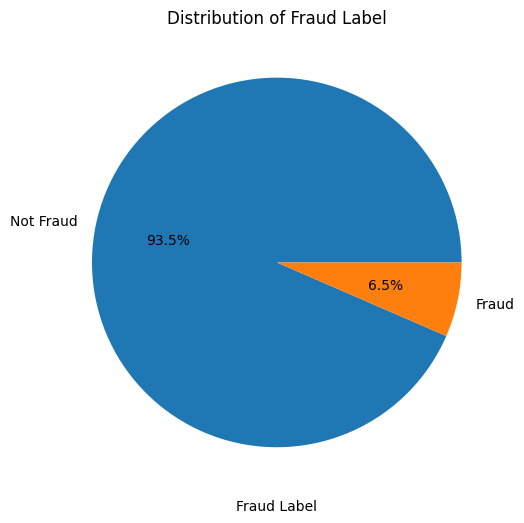

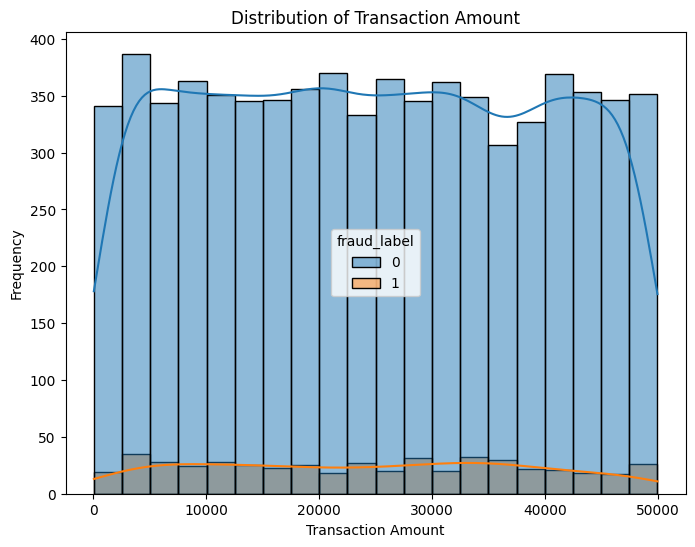

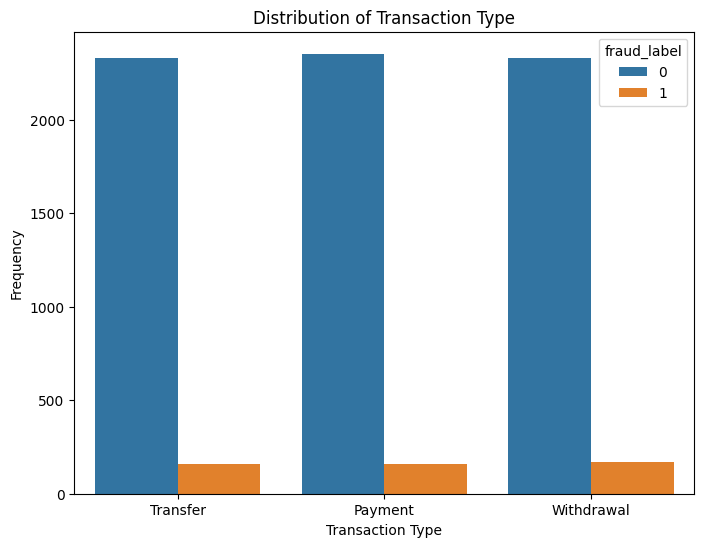

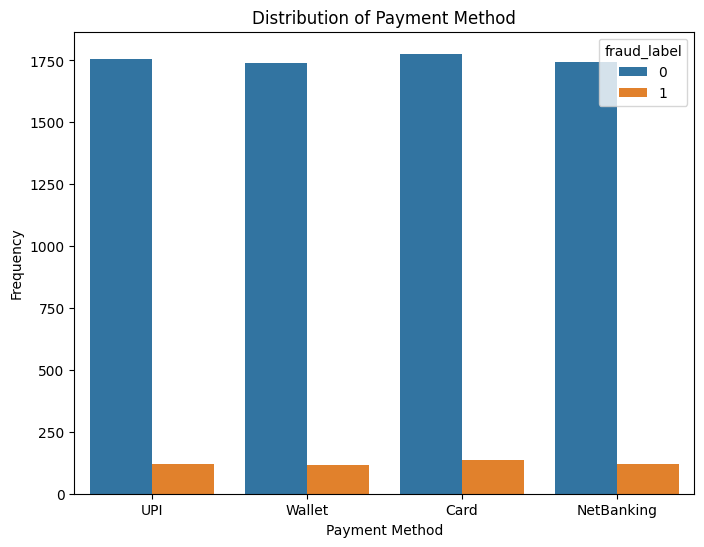

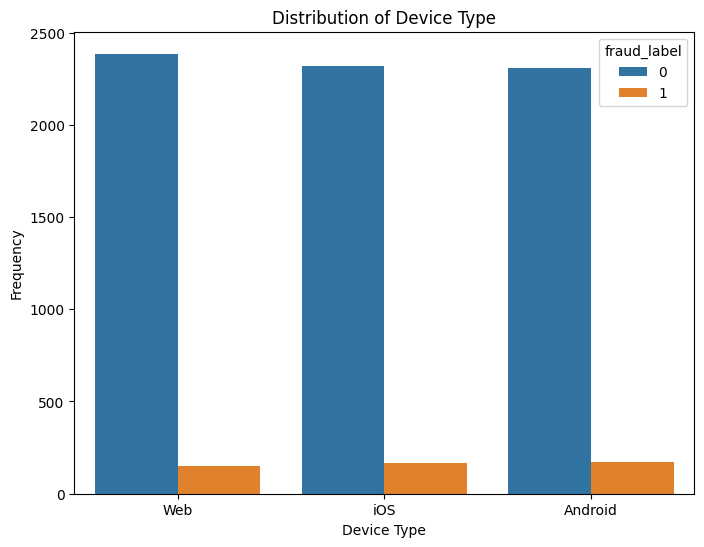

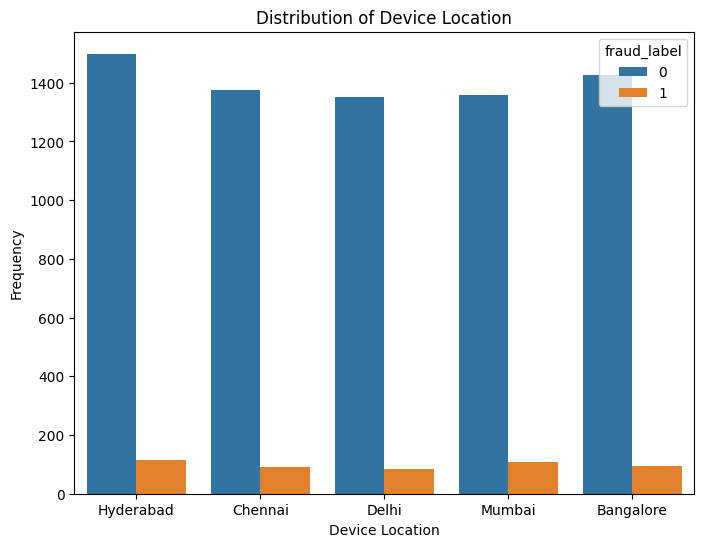

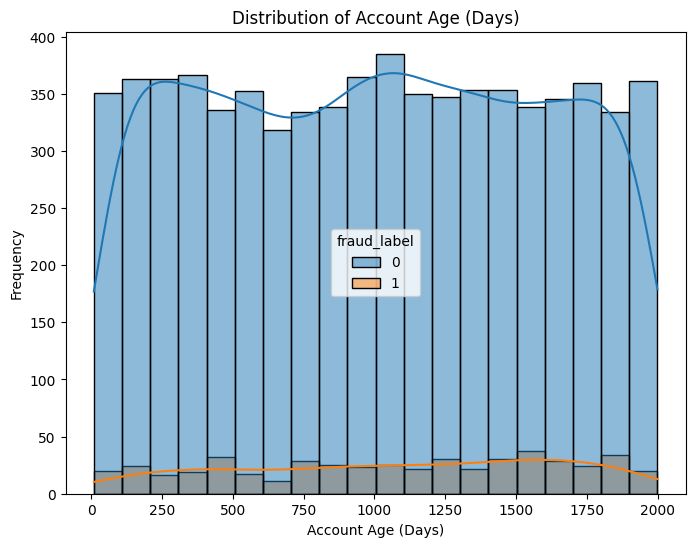

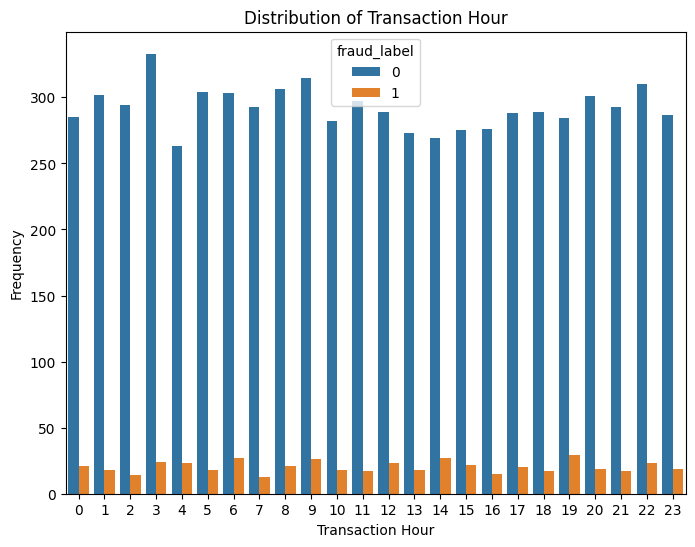

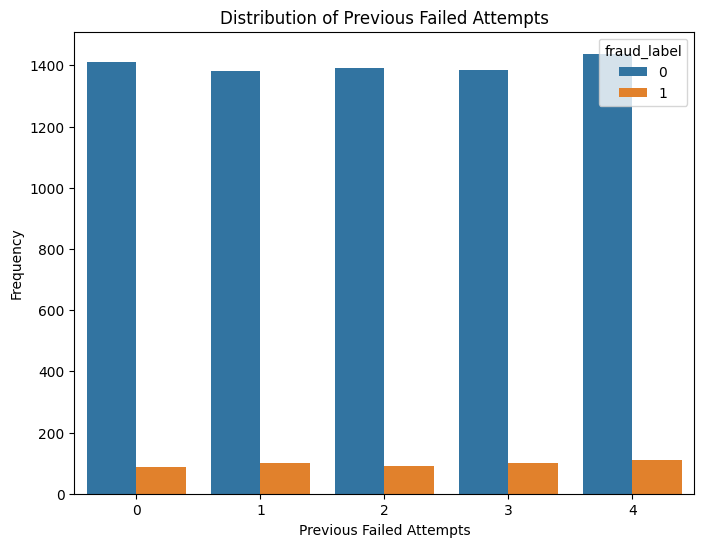

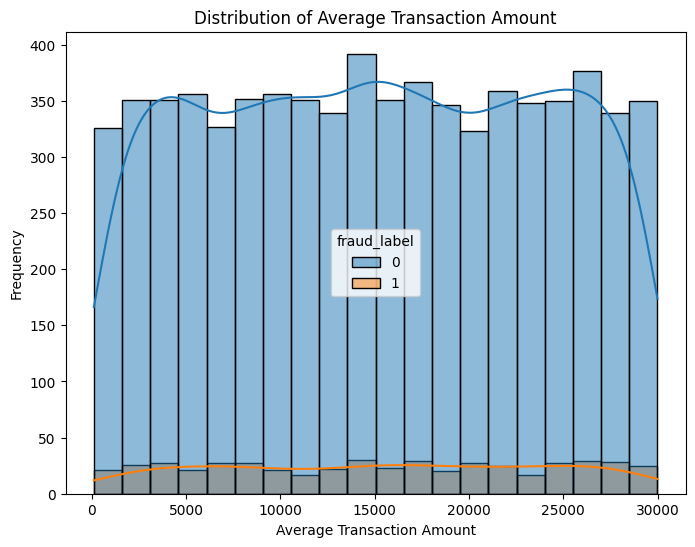

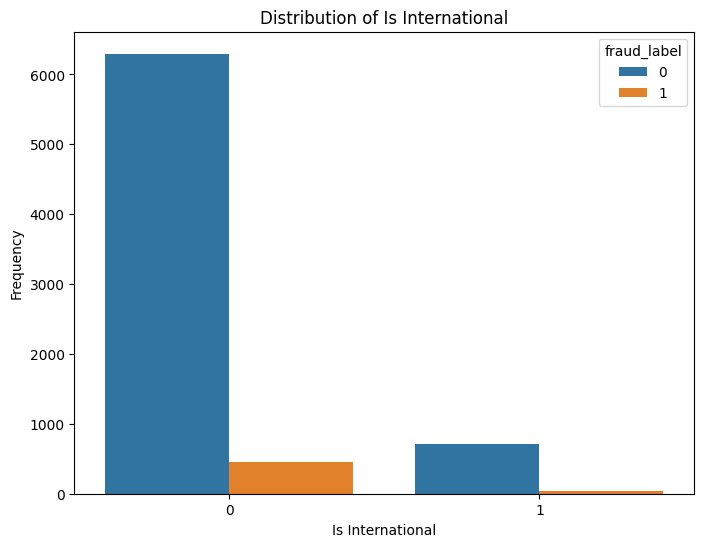

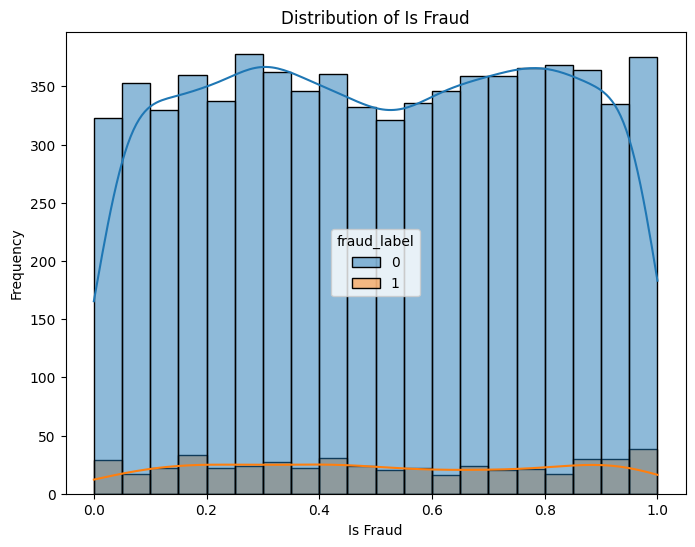

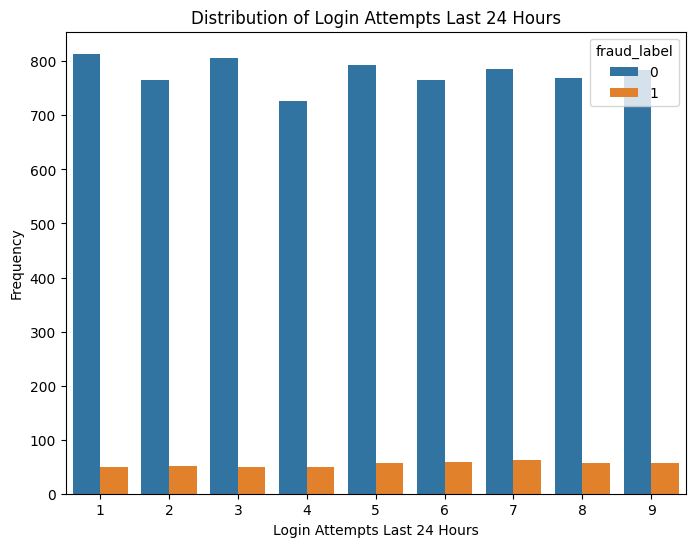

In [221]:
numerical_col = df_clean.select_dtypes(include=['number']).columns
categorical_col = df_clean.select_dtypes(exclude=['number']).columns

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(df_clean['fraud_label'].value_counts(), labels=['Not Fraud', 'Fraud'], autopct='%1.1f%%')
ax.set_title('Distribution of Fraud Label')
ax.set_xlabel('Fraud Label')

fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(x=df_clean['transaction_amount'], data=df_clean, bins=20, kde=True, ax=ax, hue='fraud_label')
ax.set_title('Distribution of Transaction Amount')
ax.set_xlabel('Transaction Amount')
ax.set_ylabel('Frequency')

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x=df_clean['transaction_type'], data=df_clean, hue='fraud_label')
ax.set_title('Distribution of Transaction Type')
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Frequency')

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x=df_clean['payment_mode'], data=df_clean, hue='fraud_label')
ax.set_title('Distribution of Payment Method')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Frequency')

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x=df_clean['device_type'], data=df_clean, hue='fraud_label')
ax.set_title('Distribution of Device Type')
ax.set_xlabel('Device Type')
ax.set_ylabel('Frequency')

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x=df_clean['device_location'], data=df_clean, hue='fraud_label')
ax.set_title('Distribution of Device Location')
ax.set_xlabel('Device Location')
ax.set_ylabel('Frequency')

fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(x=df_clean['account_age_days'], data=df_clean, bins=20, kde=True, ax=ax, hue='fraud_label')
ax.set_title('Distribution of Account Age (Days)')
ax.set_xlabel('Account Age (Days)')
ax.set_ylabel('Frequency')

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x=df_clean['transaction_hour'], data=df_clean, hue='fraud_label')
ax.set_title('Distribution of Transaction Hour')
ax.set_xlabel('Transaction Hour')
ax.set_ylabel('Frequency')

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x=df_clean['previous_failed_attempts'], data=df_clean, hue='fraud_label')
ax.set_title('Distribution of Previous Failed Attempts')
ax.set_xlabel('Previous Failed Attempts')
ax.set_ylabel('Frequency')

fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(x=df_clean['avg_transaction_amount'], data=df_clean, bins=20, kde=True, ax=ax, hue='fraud_label')
ax.set_title('Distribution of Average Transaction Amount')
ax.set_xlabel('Average Transaction Amount')
ax.set_ylabel('Frequency')

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x=df_clean['is_international'], data=df_clean, hue='fraud_label')
ax.set_title('Distribution of Is International')
ax.set_xlabel('Is International')
ax.set_ylabel('Frequency')

fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(x=df_clean['ip_risk_score'], data=df_clean, bins=20, kde=True, ax=ax, hue='fraud_label')  
ax.set_title('Distribution of Is Fraud')
ax.set_xlabel('Is Fraud')
ax.set_ylabel('Frequency')

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x=df_clean['login_attempts_last_24h'], data=df_clean, hue='fraud_label')
ax.set_title('Distribution of Login Attempts Last 24 Hours')
ax.set_xlabel('Login Attempts Last 24 Hours')
ax.set_ylabel('Frequency')

plt.show()


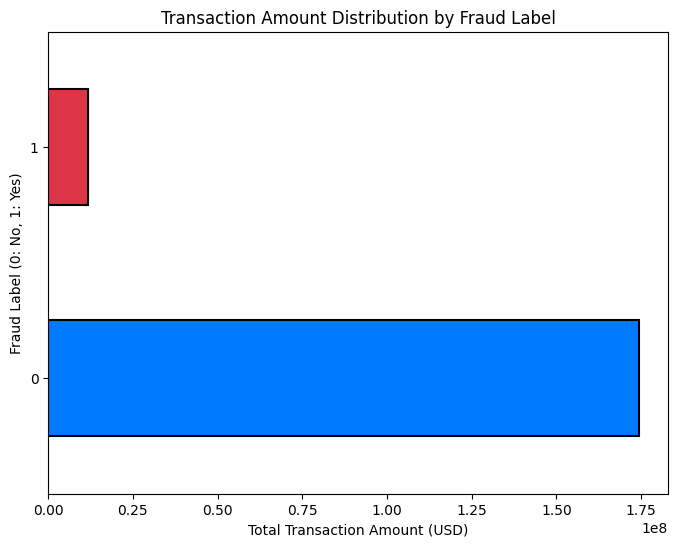

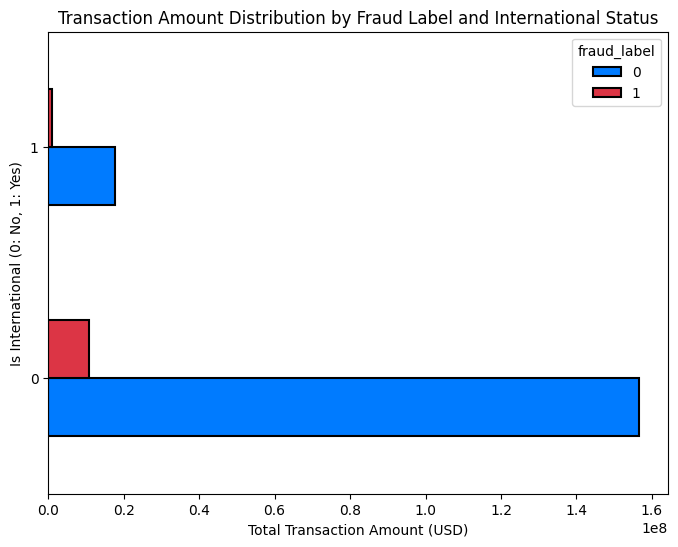

In [222]:
fig, ax = plt.subplots(figsize=(8, 6))

df_clean.groupby('fraud_label')['transaction_amount'].sum().plot(
    kind='barh', 
    ax=ax, 
    color=['#007bff', '#dc3545'], 
    edgecolor='k', 
    linewidth=1.5,
    title='Transaction Amount Distribution by Fraud Label',
    xlabel='Total Transaction Amount (USD)',
    ylabel='Fraud Label (0: No, 1: Yes)',
)

fig, ax = plt.subplots(figsize=(8, 6))
df_clean.groupby(['is_international', 'fraud_label'])['transaction_amount'].sum().unstack().plot(
    kind='barh',
    ax=ax,
    color=['#007bff', '#dc3545'],
    edgecolor='k',
    linewidth=1.5,
    title='Transaction Amount Distribution by Fraud Label and International Status',
    xlabel='Total Transaction Amount (USD)',
    ylabel='Is International (0: No, 1: Yes)',
)

plt.show()


# Data Preparation

In [223]:
df_clean['transaction_amount'] = df_clean['transaction_amount'] / 1000
df_clean['avg_transaction_amount'] = df_clean['transaction_amount'] / 10000
df_clean['is_international'] = df_clean['is_international'].map({0: 'Yes', 1: 'No'})

df_clean.head()

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18.75828,Transfer,UPI,Web,Hyderabad,895,14,1,0.001876,Yes,0.718,4,0
1,T2,U7899,47.53818,Payment,Wallet,iOS,Hyderabad,918,21,0,0.004754,Yes,0.525,9,0
2,T3,U1765,36.61310,Payment,Card,Android,Chennai,1506,8,4,0.003661,Yes,0.985,9,0
3,T4,U8850,29.95299,Payment,Wallet,iOS,Chennai,800,1,3,0.002995,Yes,0.797,2,0
4,T5,U9049,7.84313,Payment,UPI,Web,Delhi,301,4,1,0.000784,No,0.468,1,0


# Modelling

In [224]:
X = df_clean.drop(columns=['fraud_label'])
y = df_clean['fraud_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [225]:
categorical_col = X_train.select_dtypes(include=['str']).columns
numerical_col = X_train.select_dtypes(exclude=['str']).columns

numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')),
])

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_col),
    ('categorical', categorical_transformer, categorical_col),
], remainder='passthrough')

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced',
    )),
])

In [226]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

In [227]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

c:\Users\billy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\billy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


# Model Evaluation

Classification Report:
              precision    recall  f1-score   support

   not_fraud       0.93      0.98      0.96      2103
       fraud       0.03      0.01      0.01       147

    accuracy                           0.92      2250
   macro avg       0.48      0.49      0.48      2250
weighted avg       0.87      0.92      0.90      2250

Confusion Matrix:
[[2067   36]
 [ 146    1]]
ROC AUC Score:
0.49484215940299087
Precision-Recall Curve plot:


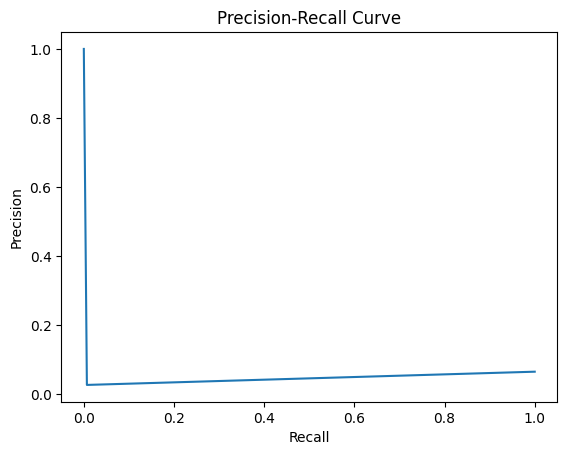

In [228]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['not_fraud', 'fraud']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC AUC Score:")
print(roc_auc_score(y_test, y_pred))
print("Precision-Recall Curve plot:")
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [229]:
model.score(X_test, y_test)

c:\Users\billy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


0.9191111111111111